<a href="https://colab.research.google.com/github/ktripa/DL_Hydrology/blob/main/SPI3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Author: Kumar Puran Tripathy (PhD, CEWS lab)
# Class: Hydroclimatic Extremes
# Instructor: Ashok Kumar Mishra
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                       ARIMA TIME SERIES ANALYSIS                            ║
# ║     Date-based Split (Train: 1901–1989 | Test: 1990–2018)                    ║
# ║         Original Series | ACF/PACF | (Next: Differencing & ARIMA)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─── 0. INSTALL & IMPORT ──────────────────────────────────────────────────────
# !pip install statsmodels openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch


from statsmodels.tsa.stattools   import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model  import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy                        import stats

# ─── GLOBAL STYLE ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#475569',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#e2e8f0',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'legend.facecolor': '#1e293b',
    'legend.edgecolor': '#475569',
})

AMBER   = '#f59e0b'
GREEN   = '#34d399'
BLUE    = '#60a5fa'
ROSE    = '#f87171'
PURPLE  = '#a78bfa'
SLATE   = '#94a3b8'




Saving Climate division 1.xlsx to Climate division 1.xlsx


  SECTION 1: LOAD DATA + DATE-BASED TRAIN/TEST SPLIT


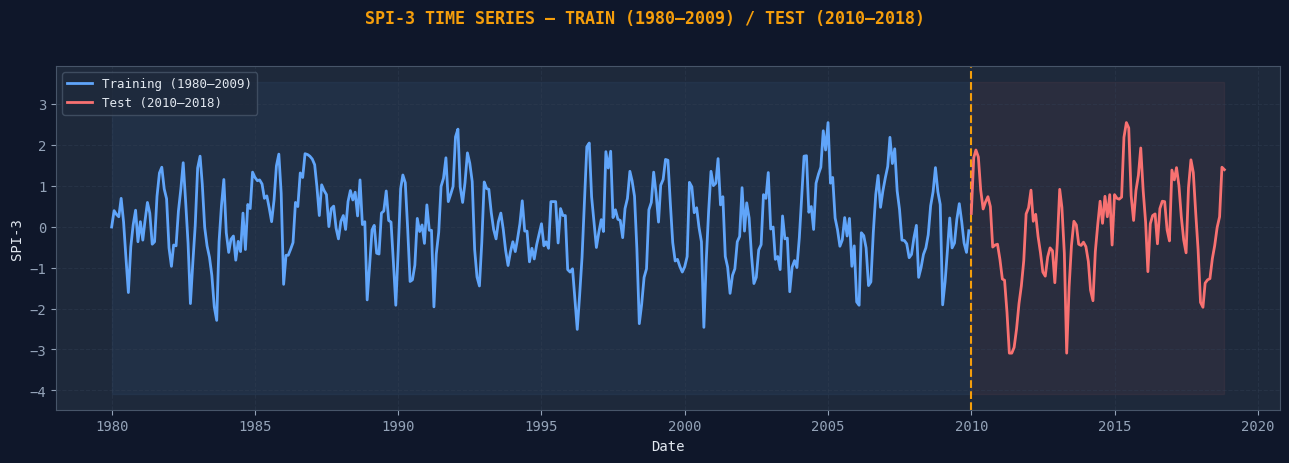

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — LOAD DATA + DATE-BASED TRAIN/TEST SPLIT
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("  SECTION 1: LOAD DATA + DATE-BASED TRAIN/TEST SPLIT")
print("=" * 70)

# --- Read Excel (robust header fix) ---
# If your Excel has headers in the first row, header=0 should work.
# But if pandas still shows "Unnamed: ..." then the header row is inside the data.
df_raw = pd.read_excel('Climate division 1.xlsx', header=0)

# If columns look like Unnamed: 0, Unnamed: 1 ... then fix using first data row
if any(str(c).startswith("Unnamed") for c in df_raw.columns):
    df_raw.columns = df_raw.iloc[0]
    df_raw = df_raw.drop(0).reset_index(drop=True)

df = df_raw.copy()



# --- Parse YearMonth into datetime ---
df['YearMonth'] = df['YearMonth'].astype(str).str.strip()
df['Year']  = df['YearMonth'].str[:4].astype(int)
df['Month'] = df['YearMonth'].str[4:].astype(int)
df['Date']  = pd.to_datetime(dict(year=df['Year'], month=df['Month'], day=1))
df = df.sort_values('Date').set_index('Date')

# --- Replace common missing-value codes with NaN (important!) ---
# In your data: -99.99 (and sometimes -9999) appear as missing.
missing_codes = [-99.99, -9999, -999.9, -99.9]
df = df.replace(missing_codes, np.nan)


y = df['SP03'].astype(float)

# --- Train/Test split by date ---
train = y.loc['1980-01-01':'2009-12-01'].copy()
test  = y.loc['2010-01-01':].copy()

# --- Drop missing values at the ends (ARIMA cannot handle NaNs) ---
train = train.dropna()
test  = test.dropna()




# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1A — PLOT RAW SERIES WITH TRAIN/TEST SPLIT
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 4.5))
fig.suptitle('SPI-3 TIME SERIES — TRAIN (1980–2009) / TEST (2010–2018)',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)

ax.plot(train.index, train.values, color=BLUE, lw=2, label='Training (1980–2009)', zorder=3)
ax.plot(test.index,  test.values,  color=ROSE, lw=2, label='Test (2010–2018)', zorder=3)

split_date = pd.to_datetime('2010-01-01')
ax.axvline(split_date, color=AMBER, lw=1.5, ls='--', zorder=2)

# Shaded regions (subtle)
ymin = min(train.min(), test.min()) - 1
ymax = max(train.max(), test.max()) + 1
ax.fill_betweenx([ymin, ymax], train.index.min(), split_date,
                 alpha=0.06, color=BLUE)
ax.fill_betweenx([ymin, ymax], split_date, test.index.max(),
                 alpha=0.06, color=ROSE)

ax.set_xlabel('Date')
ax.set_ylabel('SPI-3')
ax.grid(True, alpha=0.4)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
# plt.savefig('01_train_test_split_pdsi.png', dpi=150, bbox_inches='tight',
#             facecolor='#0f172a')
plt.show()




  SECTION 2: ORIGINAL SERIES + ACF & PACF (Training Set)


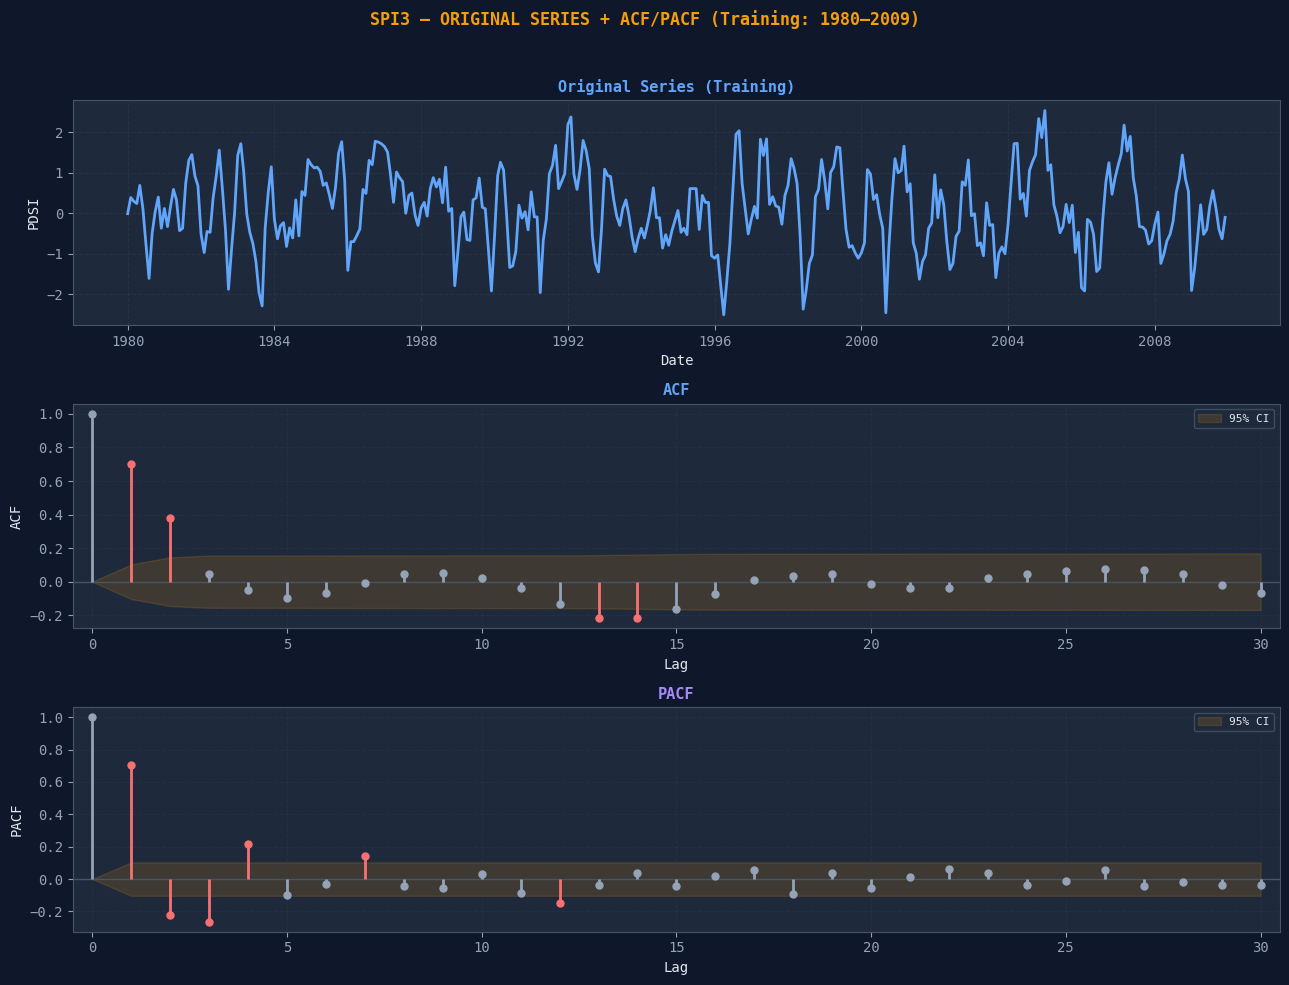

  ✓ Saved: 02_spi3_series_acf_pacf_train.png


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — ORIGINAL SERIES + ACF/PACF (TRAINING DATA) IN ONE 3×1 PANEL
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 2: ORIGINAL SERIES + ACF & PACF (Training Set)")
print("=" * 70)

def plot_series_acf_pacf_3x1(series, title, filename, nlags=40):
    series = series.dropna()

    # Compute ACF/PACF with confidence intervals for custom styling
    acf_vals, acf_ci   = acf(series, nlags=nlags, alpha=0.05)
    pacf_vals, pacf_ci = pacf(series, nlags=nlags, alpha=0.05, method='ywm')
    lags = np.arange(nlags + 1)

    fig, axes = plt.subplots(3, 1, figsize=(13, 10))
    fig.suptitle(title, fontsize=12, color=AMBER, fontweight='bold', y=0.98)

    # ── (1) Time series plot ────────────────────────────────────────────────
    axes[0].plot(series.index, series.values, color=BLUE, lw=2)
    axes[0].set_title('Original Series (Training)', color=BLUE, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('PDSI')
    axes[0].grid(True, alpha=0.4)

    # Helper: stem plot with CI shading (matches your style)
    def styled_corr_plot(ax, vals, ci, label, title_color):
        ci_lower = ci[:, 0] - vals
        ci_upper = ci[:, 1] - vals

        ax.fill_between(lags, ci_lower, ci_upper, alpha=0.15, color=AMBER, label='95% CI')
        ax.axhline(0, color='#475569', lw=1)

        for lag in lags[1:]:
            # mark significant lags in ROSE
            c = ROSE if (vals[lag] < ci_lower[lag]) or (vals[lag] > ci_upper[lag]) else SLATE
            ax.vlines(lag, 0, vals[lag], colors=c, lw=2)
            ax.plot(lag, vals[lag], 'o', color=c, ms=5, zorder=3)

        ax.vlines(0, 0, vals[0], colors=SLATE, lw=2)
        ax.plot(0, vals[0], 'o', color=SLATE, ms=5)

        ax.set_xlim(-0.5, nlags + 0.5)
        ax.set_xlabel('Lag')
        ax.set_ylabel(label)
        ax.set_title(label, color=title_color, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')

    # ── (2) ACF ─────────────────────────────────────────────────────────────
    styled_corr_plot(axes[1], acf_vals, acf_ci, 'ACF', BLUE)

    # ── (3) PACF ────────────────────────────────────────────────────────────
    styled_corr_plot(axes[2], pacf_vals, pacf_ci, 'PACF', PURPLE)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
    print(f"  ✓ Saved: {filename}")

plot_series_acf_pacf_3x1(
    train,
    'SPI3 — ORIGINAL SERIES + ACF/PACF (Training: 1980–2009)',
    '02_spi3_series_acf_pacf_train.png',
    nlags=30
)

## SPI-3 (Training) — What the plots say

- ACF: big spikes at lags **1–2**, then **dies out fast** (no slow decay).
- PACF: strongest spike at **lag 1**, smaller spikes up to **~lag 4**.
- Series oscillates around ~0 with stable variance.

**Conclusion: NO differencing needed (d = 0).**  
So we fit **ARIMA(p,0,q)**.

Candidate logic:
- AR part suggested by PACF (p ≈ 1–4)
- MA part suggested by ACF (q ≈ 1–2)

We’ll compare candidate models using **AIC/BIC** and pick the best (lower is better).


  SECTION 4: SPI-3 CANDIDATE ARIMA MODELS — AIC / BIC COMPARISON

  Model                 AIC        BIC       HQIC     LogLik           σ²
  --------------------------------------------------------------
  ARIMA(1, 0, 0)    753.881    765.539    758.517   -373.941       0.4666
  ARIMA(2, 0, 0)    738.119    753.664    744.300   -365.060       0.4440
  ARIMA(3, 0, 0)    714.596    734.027    722.322   -352.298       0.4134
  ARIMA(4, 0, 0)    699.362    722.678    708.633   -343.681       0.3939
  ARIMA(1, 0, 1)    746.435    761.979    752.615   -369.217       0.4545
  ARIMA(2, 0, 1)    730.830    750.260    738.556   -360.415       0.4327
  ARIMA(1, 0, 2)    685.036    704.466    692.762   -337.518       0.3805
  ARIMA(2, 0, 2)    686.915    710.232    696.186   -337.458       0.3804

  Best model by AIC: ARIMA(1, 0, 2)


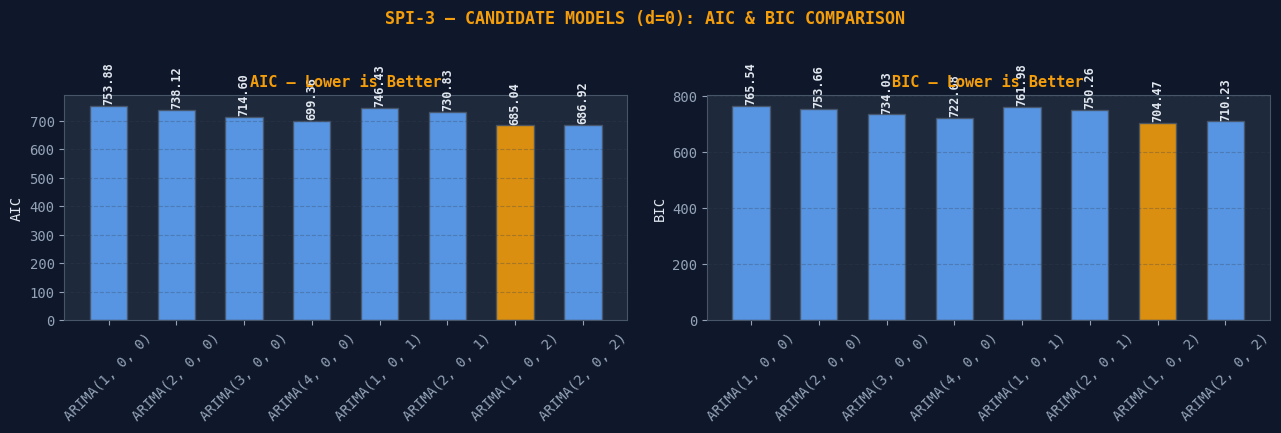

  ✓ Saved: 05_spi3_model_comparison.png


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — SPI-3 CANDIDATE MODELS: FIT & COMPARE (AIC / BIC)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("  SECTION 4: SPI-3 CANDIDATE ARIMA MODELS — AIC / BIC COMPARISON")
print("=" * 70)

# d = 0 (NO differencing)
candidate_orders = [
    (1,0,0), (2,0,0), (3,0,0), (4,0,0),   # AR(1–4)
    (1,0,1), (2,0,1),                     # ARMA with q=1
    (1,0,2), (2,0,2)                      # ARMA with q=2
]

model_results = {}

print(f"\n  {'Model':<14} {'AIC':>10} {'BIC':>10} {'HQIC':>10} {'LogLik':>10} {'σ²':>12}")
print("  " + "-" * 62)

for order in candidate_orders:
    mod = ARIMA(train, order=order).fit()
    model_results[order] = mod
    sig2 = np.var(mod.resid)
    print(f"  ARIMA{str(order):<9} {mod.aic:>10.3f} {mod.bic:>10.3f} "
          f"{mod.hqic:>10.3f} {mod.llf:>10.3f} {sig2:>12.4f}")

# Best by AIC
best_order = min(model_results, key=lambda o: model_results[o].aic)
print(f"\n  Best model by AIC: ARIMA{best_order}")

# ── Plot AIC/BIC comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
fig.suptitle('SPI-3 — CANDIDATE MODELS (d=0): AIC & BIC COMPARISON',
             fontsize=12, color=AMBER, fontweight='bold', y=1.02)

labels   = [f'ARIMA{o}' for o in candidate_orders]
aic_vals = [model_results[o].aic for o in candidate_orders]
bic_vals = [model_results[o].bic for o in candidate_orders]

colors = [AMBER if o == best_order else BLUE for o in candidate_orders]

for ax, vals, metric in [(axes[0], aic_vals, 'AIC'),
                         (axes[1], bic_vals, 'BIC')]:
    bars = ax.bar(labels, vals, color=colors, edgecolor='#475569',
                  width=0.55, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.05*(max(vals)-min(vals)),
                f'{v:.2f}', ha='center', va='bottom', fontsize=8.5,
                color='#e2e8f0', fontweight='bold', rotation=90)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Lower is Better', color=AMBER, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('05_spi3_model_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0f172a')
plt.show()
print("  ✓ Saved: 05_spi3_model_comparison.png")